1. Import Libraries

In [8]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import warnings

warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


2. Upload Dataset

In [9]:
# ============================================================
# 2. UPLOAD DATASET
# ============================================================

try:
    from google.colab import files  # type: ignore  # pyright: ignore[reportMissingImports]
    uploaded = files.upload()
    print("\nUploaded files:")
    for filename in uploaded.keys():
        print("-", filename)
except ImportError:
    print("[*] Local environment detected. Skipping google.colab interactive file upload.")


Saving Lead Scoring.csv to Lead Scoring.csv
Saving Leads Data Dictionary.xlsx to Leads Data Dictionary.xlsx

Uploaded files:
- Lead Scoring.csv
- Leads Data Dictionary.xlsx


3. Load Dataset

In [10]:
import pandas as pd
import os

candidates = [
    'Lead Scoring.csv',
    os.path.join('..', 'data', 'Lead Scoring.csv'),
    os.path.join('ml', 'data', 'Lead Scoring.csv'),
    r'd:\Intelligent CRM & Lead Conversion Analytics\lead-conversion-sales-intelligence\predictive-lead-scoring-crm\ml\data\Lead Scoring.csv'
]
DATA_FILE = next((p for p in candidates if os.path.exists(p)), candidates[-1])

df = pd.read_csv(DATA_FILE)

print('Dataset loaded successfully from:', DATA_FILE)
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

df.head()


Dataset loaded successfully!
Rows: 9240
Columns: 37
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']
(9240, 37)


4. Understand Dataset

 4.1 DATASET SHAPE

In [11]:
# ============================================================
# 4.1 DATASET SHAPE
# ============================================================

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(9240, 37)


4.2 Column names

In [12]:
# ============================================================
# 4.2 COLUMN NAMES
# ============================================================

print("Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:

1. Prospect ID
2. Lead Number
3. Lead Origin
4. Lead Source
5. Do Not Email
6. Do Not Call
7. Converted
8. TotalVisits
9. Total Time Spent on Website
10. Page Views Per Visit
11. Last Activity
12. Country
13. Specialization
14. How did you hear about X Education
15. What is your current occupation
16. What matters most to you in choosing a course
17. Search
18. Magazine
19. Newspaper Article
20. X Education Forums
21. Newspaper
22. Digital Advertisement
23. Through Recommendations
24. Receive More Updates About Our Courses
25. Tags
26. Lead Quality
27. Update me on Supply Chain Content
28. Get updates on DM Content
29. Lead Profile
30. City
31. Asymmetrique Activity Index
32. Asymmetrique Profile Index
33. Asymmetrique Activity Score
34. Asymmetrique Profile Score
35. I agree to pay the amount through cheque
36. A free copy of Mastering The Interview
37. Last Notable Activity


4.3 Dataset information

In [13]:
# ============================================================
# 4.3 DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

4.4 First 10 rows

In [14]:
df.head(10)

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified
5,2058ef08-2858-443e-a01f-a9237db2f5ce,660680,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,NaN,NaN,01.High,02.Medium,17.0,15.0,No,No,Modified
6,9fae7df4-169d-489b-afe4-0f3d752542ed,660673,Landing Page Submission,Google,No,No,1,2.0,1640,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,No,Modified
7,20ef72a2-fb3b-45e0-924e-551c5fa59095,660664,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,NaN,NaN,02.Medium,02.Medium,15.0,15.0,No,No,Modified
8,cfa0128c-a0da-4656-9d47-0aa4e67bf690,660624,Landing Page Submission,Direct Traffic,No,No,0,2.0,71,2.0,...,No,NaN,Thane & Outskirts,02.Medium,02.Medium,14.0,14.0,No,Yes,Email Opened
9,af465dfc-7204-4130-9e05-33231863c4b5,660616,API,Google,No,No,0,4.0,58,4.0,...,No,NaN,Mumbai,02.Medium,02.Medium,13.0,16.0,No,No,Email Opened


4.5 Statistical summary

In [15]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Prospect ID,9240,9240,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead Number,9240.0,NaN,NaN,NaN,617188.435606,23405.995698,579533.0,596484.5,615479.0,637387.25,660737.0
Lead Origin,9240,5,Landing Page Submission,4886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead Source,9204,21,Google,2868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do Not Email,9240,2,No,8506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do Not Call,9240,2,No,9238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Converted,9240.0,NaN,NaN,NaN,0.38539,0.486714,0.0,0.0,0.0,1.0,1.0
TotalVisits,9103.0,NaN,NaN,NaN,3.445238,4.854853,0.0,1.0,3.0,5.0,251.0
Total Time Spent on Website,9240.0,NaN,NaN,NaN,487.698268,548.021466,0.0,12.0,248.0,936.0,2272.0
Page Views Per Visit,9103.0,NaN,NaN,NaN,2.36282,2.161418,0.0,1.0,2.0,3.0,55.0


4.6 Target distribution

In [16]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

print("Converted value counts:")
print(df["Converted"].value_counts())

print("\nConverted percentage:")
print(
    (df["Converted"].value_counts(normalize=True) * 100)
    .round(2)
)

Converted value counts:
Converted
0    5679
1    3561
Name: count, dtype: int64

Converted percentage:
Converted
0    61.46
1    38.54
Name: proportion, dtype: float64


5.1 Check missing values

In [21]:
# ============================================================
# 5.1 MISSING VALUES
# ============================================================

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

print("Columns containing missing values:\n")
print(missing)

Columns containing missing values:

How did you hear about X Education               7250
Lead Profile                                     6855
Lead Quality                                     4767
Asymmetrique Activity Index                      4218
Asymmetrique Profile Index                       4218
Asymmetrique Profile Score                       4218
Asymmetrique Activity Score                      4218
City                                             3669
Specialization                                   3380
Tags                                             3353
What matters most to you in choosing a course    2709
What is your current occupation                  2690
Country                                          2461
Page Views Per Visit                              137
TotalVisits                                       137
Last Activity                                     103
Lead Source                                        36
dtype: int64


5.2 Check duplicates

In [20]:
# ============================================================
# 5.2 DUPLICATES
# ============================================================

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (9240, 37)


5.3 Standardize missing-value representations

In [19]:
# ============================================================
# 5.3 STANDARDIZE MISSING VALUES
# ============================================================

df = df.replace(
    ["Select", "select", "Not Specified", "Not specified"],
    np.nan
)

print("Missing values after standardization:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Missing values after standardization:
How did you hear about X Education               7250
Lead Profile                                     6855
Lead Quality                                     4767
Asymmetrique Profile Index                       4218
Asymmetrique Activity Index                      4218
Asymmetrique Activity Score                      4218
Asymmetrique Profile Score                       4218
City                                             3669
Specialization                                   3380
Tags                                             3353
What matters most to you in choosing a course    2709
What is your current occupation                  2690
Country                                          2461
Page Views Per Visit                              137
TotalVisits                                       137
Last Activity                                     103
Lead Source                                        36
Do Not Email                                

5.4 Make target numeric

In [22]:
# ============================================================
# 5.4 CONVERT TARGET TO INTEGER
# ============================================================

df["Converted"] = pd.to_numeric(
    df["Converted"],
    errors="coerce"
)

df = df.dropna(subset=["Converted"])

df["Converted"] = df["Converted"].astype(int)

print(df["Converted"].value_counts())

Converted
0    5679
1    3561
Name: count, dtype: int64


6. Exploratory Data Analysis

6.1 Conversion distribution

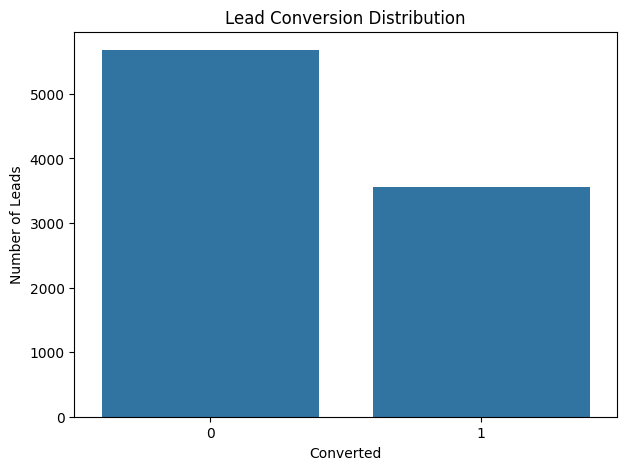

In [23]:
# ============================================================
# 6.1 CONVERSION DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    x=df["Converted"]
)

plt.title("Lead Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Number of Leads")

plt.show()

6.2 Conversion percentage

In [24]:
conversion_rate = df["Converted"].mean() * 100

print(
    f"Overall conversion rate: {conversion_rate:.2f}%"
)

Overall conversion rate: 38.54%


6.3 Numerical correlation

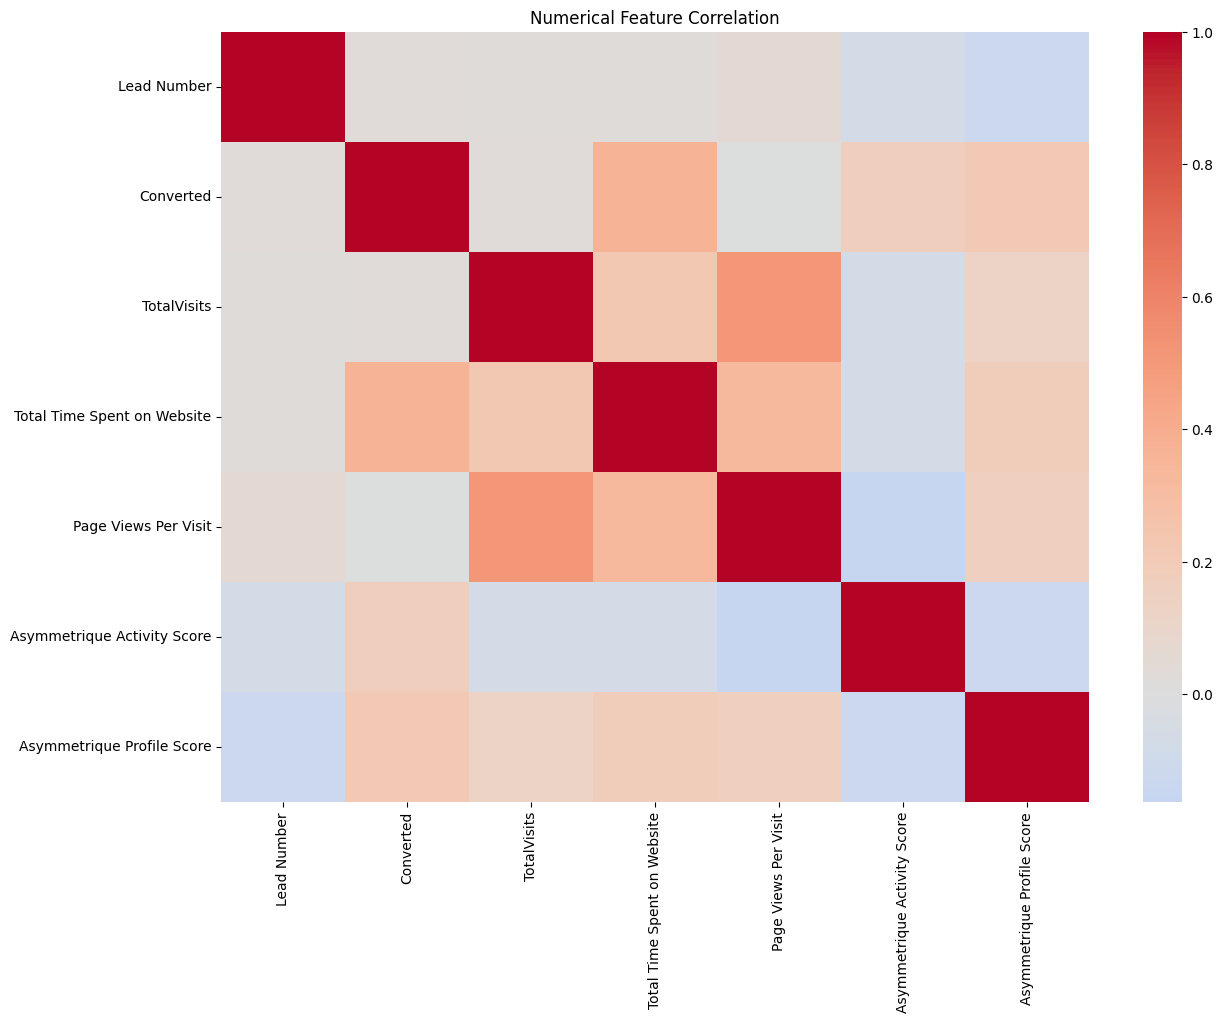

In [25]:
# ============================================================
# 6.3 CORRELATION MATRIX
# ============================================================

numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation")
plt.show()

6.4 Conversion by Lead Source

Lead Source
Live Chat            100.000000
WeLearn              100.000000
NC_EDM               100.000000
Welingak Website      98.591549
Reference             91.760300
Click2call            75.000000
Social Media          50.000000
Google                39.993026
Organic Search        37.781629
Direct Traffic        32.166732
Olark Chat            25.527066
Referral Sites        24.800000
Facebook              23.636364
bing                  16.666667
Pay per Click Ads      0.000000
Press_Release          0.000000
blog                   0.000000
google                 0.000000
testone                0.000000
welearnblog_Home       0.000000
youtubechannel         0.000000
Name: Converted, dtype: float64


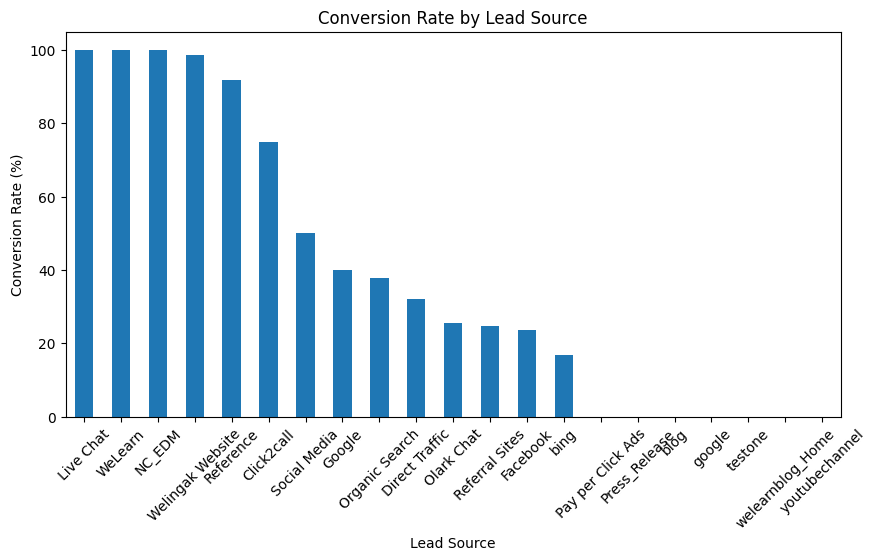

In [26]:
# ============================================================
# 6.4 CONVERSION BY LEAD SOURCE
# ============================================================

if "Lead Source" in df.columns:

    conversion_by_source = (
        df.groupby("Lead Source")["Converted"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print(conversion_by_source)

    conversion_by_source.plot(
        kind="bar",
        figsize=(10, 5)
    )

    plt.title("Conversion Rate by Lead Source")
    plt.ylabel("Conversion Rate (%)")
    plt.xlabel("Lead Source")
    plt.xticks(rotation=45)
    plt.show()

6.5 Conversion by Occupation

In [27]:
# ============================================================
# 6.5 CONVERSION BY OCCUPATION
# ============================================================


if "Occupation" in df.columns:
    occupation_conversion = (
        df.groupby("Occupation")["Converted"]
        .mean()
        .sort_values(ascending=False)
        .dropna()
    )

    plt.figure(figsize=(10, 6))
    occupation_conversion.plot(kind="bar")
    plt.title("Conversion Rate by Occupation")
    plt.xlabel("Occupation")
    plt.ylabel("Conversion Rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

else:
    print("Occupation column not found.")
    print("Available columns:")
    print(df.columns.tolist())

Occupation column not found.
Available columns:
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


7. Feature Selection

In [28]:
# ============================================================
# 7. FEATURE SELECTION
# ============================================================

TARGET = "Converted"

# Columns that should NOT be used as ML features
DROP_COLUMNS = [
    "Converted",
    "Prospect ID",
    "Lead Number",
    "Lead Quality",
    "Tags"
]

# Only drop columns that actually exist
DROP_COLUMNS = [
    col for col in DROP_COLUMNS
    if col in df.columns
]

print("Columns removed:")
for col in DROP_COLUMNS:
    print("-", col)

X = df.drop(
    columns=DROP_COLUMNS
)

y = df[TARGET]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nSelected features:\n")

for i, column in enumerate(X.columns, start=1):
    print(f"{i}. {column}")

Columns removed:
- Converted
- Prospect ID
- Lead Number
- Lead Quality
- Tags

Feature matrix shape: (9240, 32)
Target shape: (9240,)

Selected features:

1. Lead Origin
2. Lead Source
3. Do Not Email
4. Do Not Call
5. TotalVisits
6. Total Time Spent on Website
7. Page Views Per Visit
8. Last Activity
9. Country
10. Specialization
11. How did you hear about X Education
12. What is your current occupation
13. What matters most to you in choosing a course
14. Search
15. Magazine
16. Newspaper Article
17. X Education Forums
18. Newspaper
19. Digital Advertisement
20. Through Recommendations
21. Receive More Updates About Our Courses
22. Update me on Supply Chain Content
23. Get updates on DM Content
24. Lead Profile
25. City
26. Asymmetrique Activity Index
27. Asymmetrique Profile Index
28. Asymmetrique Activity Score
29. Asymmetrique Profile Score
30. I agree to pay the amount through cheque
31. A free copy of Mastering The Interview
32. Last Notable Activity


8. Data Preprocessing

In [29]:
# ============================================================
# 8. DATA PREPROCESSING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessor created successfully!")

Numerical features:
['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']

Categorical features:
['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']

Preprocessor created successfully!


9. Train Test Split

In [30]:
# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7392, 32)
Testing data: (1848, 32)


10. Logistic Regression

In [31]:
# ============================================================
# 10. LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


11. Random Forest

In [32]:
# ============================================================
# 11. RANDOM FOREST
# ============================================================

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


12. XGBoost

In [33]:
# ============================================================
# 12. XGBOOST
# ============================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count / positive_count
)

print(
    "XGBoost scale_pos_weight:",
    scale_pos_weight
)
xgboost_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=400,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training XGBoost...")

xgboost_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

XGBoost scale_pos_weight: 1.5945945945945945
Training XGBoost...
XGBoost training completed!


13. Model Evaluation

In [34]:
# ============================================================
# 13. MODEL EVALUATION
# ============================================================

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    y_probability = model.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Not Converted",
                "Converted"
            ],
            zero_division=0
        )
    )


Logistic Regression
               precision    recall  f1-score   support

Not Converted       0.87      0.82      0.85      1136
    Converted       0.74      0.81      0.77       712

     accuracy                           0.82      1848
    macro avg       0.81      0.82      0.81      1848
 weighted avg       0.82      0.82      0.82      1848


Random Forest
               precision    recall  f1-score   support

Not Converted       0.87      0.83      0.85      1136
    Converted       0.75      0.81      0.78       712

     accuracy                           0.82      1848
    macro avg       0.81      0.82      0.82      1848
 weighted avg       0.83      0.82      0.82      1848


XGBoost
               precision    recall  f1-score   support

Not Converted       0.89      0.84      0.86      1136
    Converted       0.76      0.83      0.80       712

     accuracy                           0.83      1848
    macro avg       0.82      0.83      0.83      1848
 weighted av

14. Model Comparison

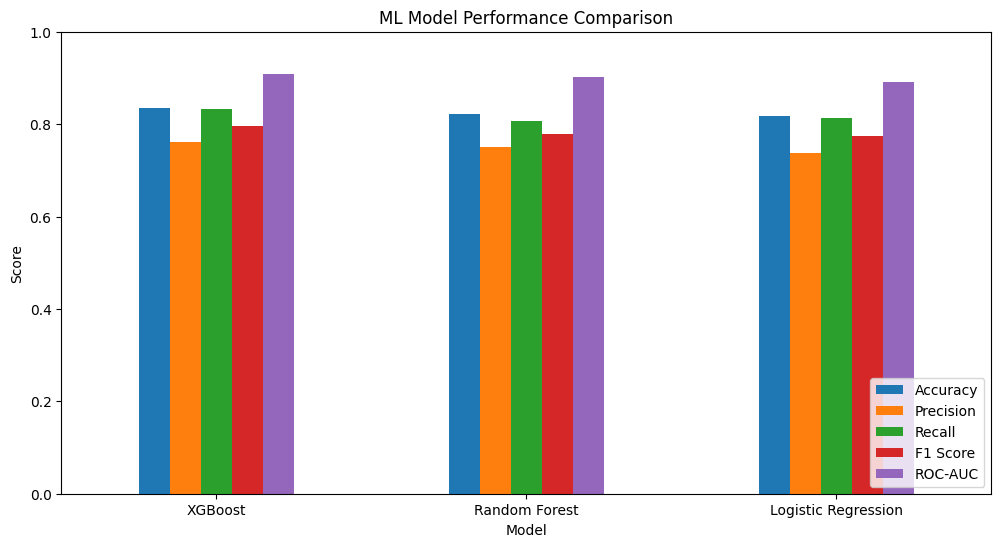

In [35]:
# ============================================================
# 14. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df
# ============================================================
# MODEL COMPARISON CHART
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_plot = results_df.set_index("Model")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

15. Feature Importance

In [36]:
# ============================================================
# 15. FEATURE IMPORTANCE
# ============================================================

# Get the fitted preprocessor from XGBoost
fitted_preprocessor = (
    xgboost_model
    .named_steps["preprocessor"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(feature_names)
)
import json
import os
import joblib

print("Libraries imported successfully!")

Number of transformed features: 167
Libraries imported successfully!


16. Save Best Model

In [38]:
# ============================================================
# SAVE MODEL METADATA
# ============================================================

import os
import json

# Make sure folder exists
os.makedirs("saved_models", exist_ok=True)

metadata = {
    "model_name": "XGBoost",
    "target": "Converted",
    "feature_columns": X.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "dropped_columns": DROP_COLUMNS,
    "roc_auc": 0.9086
}

with open("saved_models/model_metadata.json", "w") as file:
    json.dump(metadata, file, indent=4)

print("Model metadata saved successfully!")

Model metadata saved successfully!


In [42]:
import os

os.makedirs("saved_models", exist_ok=True)

print("Files in saved_models:")
print(os.listdir("saved_models"))
import joblib

joblib.dump(
    xgboost_model,
    "saved_models/lead_conversion_model.pkl"
)

print("Model saved successfully!")
import os

print(os.listdir("saved_models"))

Files in saved_models:
['lead_conversion_model.pkl', 'model_metadata.json']
Model saved successfully!
['lead_conversion_model.pkl', 'model_metadata.json']


In [43]:
# ============================================================
# 2. UPLOAD DATASET
# ============================================================

try:
    from google.colab import files  # type: ignore  # pyright: ignore[reportMissingImports]
    uploaded = files.upload()
    print("\nUploaded files:")
    for filename in uploaded.keys():
        print("-", filename)
except ImportError:
    print("[*] Local environment detected. Skipping google.colab interactive file upload.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

17. Test New Lead

In [44]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir())

print("\nSaved_models exists?")
print(os.path.exists("saved_models"))

if os.path.exists("saved_models"):
    print("\nInside saved_models:")
    print(os.listdir("saved_models"))

Current directory:
/content

Files and folders:
['.config', 'Lead Scoring.csv', 'saved_models', 'Leads Data Dictionary.xlsx', 'sample_data']

Saved_models exists?
True

Inside saved_models:
['lead_conversion_model.pkl', 'model_metadata.json']


Convert score into HOT/WARM/COLD

In [46]:
# ============================================================
# LEAD PREDICTION + TEMPERATURE
# ============================================================

import joblib

# Load trained model
model = joblib.load(
    "saved_models/lead_conversion_model.pkl"
)

# Select one test lead
new_lead = X_test.iloc[[0]]

# Predict
prediction = model.predict(new_lead)[0]

# Conversion probability
probability = model.predict_proba(new_lead)[0][1]

# Convert probability to score
lead_score = probability * 100


# Determine temperature
def get_lead_temperature(score):

    if score >= 80:
        return "HOT"

    elif score >= 50:
        return "WARM"

    else:
        return "COLD"


temperature = get_lead_temperature(lead_score)


# Display result
print("=" * 50)
print("       LEAD CONVERSION PREDICTION")
print("=" * 50)

print(f"Conversion Probability : {probability:.4f}")
print(f"Lead Score             : {lead_score:.2f}")
print(f"Lead Temperature       : {temperature}")
print(f"Predicted Class        : {prediction}")

print("=" * 50)

       LEAD CONVERSION PREDICTION
Conversion Probability : 0.8634
Lead Score             : 86.34
Lead Temperature       : HOT
Predicted Class        : 1


Create a CRM Prediction Function

In [51]:
# ============================================================
# CRM LEAD SCORING FUNCTION
# ============================================================

import pandas as pd


def predict_lead(lead_data, model):

    # Convert dictionary to DataFrame
    lead_df = pd.DataFrame([lead_data])

    # Get conversion probability
    probability = model.predict_proba(lead_df)[0][1]

    # Convert probability to score
    score = probability * 100

    # Determine temperature
    if score >= 80:
        temperature = "HOT"
    elif score >= 50:
        temperature = "WARM"
    else:
        temperature = "COLD"

    return {
        "conversion_probability": round(probability, 4),
        "lead_score": round(score, 2),
        "temperature": temperature
    }


print("CRM Lead Scoring Function created successfully!")
# ============================================================
# TEST CRM LEAD SCORING
# ============================================================

# Take one existing lead from the test dataset
test_lead = X_test.iloc[0].to_dict()

# Predict
result = predict_lead(
    test_lead,
    xgboost_model
)

print("=" * 50)
print("CRM LEAD SCORING RESULT")
print("=" * 50)

print("Conversion Probability:",
      result["conversion_probability"])

print("Lead Score:",
      result["lead_score"])

print("Temperature:",
      result["temperature"])

print("=" * 50)


CRM Lead Scoring Function created successfully!
CRM LEAD SCORING RESULT
Conversion Probability: 0.8634
Lead Score: 86.34
Temperature: HOT
